In [1]:
import numpy as np
import pandas as pd 
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
import pandas as pd
os.chdir('..')  # Go up to project root
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input/broad-peak.csv
./kaggle/input/lhotse.csv
./kaggle/input/kangchenjunga.csv
./kaggle/input/.DS_Store
./kaggle/input/cho-oyu.csv
./kaggle/input/manaslu.csv
./kaggle/input/dhaulagiri-I.csv
./kaggle/input/EVER.parquet
./kaggle/input/everest.csv
./kaggle/input/k2.csv
./kaggle/input/nanga-parbat.csv
./kaggle/input/gasherbrum-II.csv
./kaggle/input/shishapangma.csv
./kaggle/input/gasherbrum-I.csv
./kaggle/input/annapurna-I.csv
./kaggle/input/deaths_by_year_mountain.csv
./kaggle/input/makalu.csv


In [2]:
everest = pd.read_csv('./kaggle/input/everest.csv')
everesttemps = pd.read_parquet('./kaggle/input/EVER.parquet')

In [3]:
# First, convert date to just date (no time)
everesttemps['date_only'] = pd.to_datetime(everesttemps['date']).dt.date

# Group by date and aggregate
# Use mode for categorical/weather columns, mean for numerical measurements
daily_everest = everesttemps.groupby('date_only').agg({
    'peakid': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],  # Mode
    'temperature_2m': 'mean',  # Average temperature
    'relative_humidity_2m': 'mean',  # Average humidity
    'precipitation': 'sum',  # Total precipitation
    'rain': 'sum',  # Total rain
    'snowfall': 'sum',  # Total snowfall
    'wind_speed_100m': 'mean',  # Average wind speed
    'wind_direction_100m': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],  # Mode
    'weather_code': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],  # Mode
    'surface_pressure': 'mean',  # Average pressure
    'et0_fao_evapotranspiration': 'sum',  # Total evapotranspiration
    'vapour_pressure_deficit': 'mean',  # Average VPD
    'snow_depth': 'mean',  # Average snow depth
    'shortwave_radiation': 'sum',  # Total radiation
    'direct_radiation': 'sum',  # Total direct radiation
    'diffuse_radiation': 'sum'  # Total diffuse radiation
}).reset_index()

print(f"Original dataset: {len(everesttemps)} rows (hourly)")
print(f"Aggregated dataset: {len(daily_everest)} rows (daily)")
print(daily_everest.head())

Original dataset: 394488 rows (hourly)
Aggregated dataset: 16437 rows (daily)
    date_only peakid  temperature_2m  relative_humidity_2m  precipitation  \
0  1980-01-01   EVER      -41.080914             61.184116            4.2   
1  1980-01-02   EVER      -43.249664             25.218580            2.0   
2  1980-01-03   EVER      -44.057999             11.458504            0.5   
3  1980-01-04   EVER      -42.401749              6.349964            0.0   
4  1980-01-05   EVER      -42.583000              6.322521            0.6   

   rain  snowfall  wind_speed_100m  wind_direction_100m  weather_code  \
0   0.0      3.36        11.182387           234.462234            71   
1   0.0      1.82        12.834381           228.366547            71   
2   0.0      1.68        11.404770           232.431335            71   
3   0.0      1.61        10.690829           236.309906            71   
4   0.0      1.61         9.154526           236.309906            71   

   surface_pressure 

In [4]:
# Convert both to the same datetime format (no .date())
everest['Date'] = pd.to_datetime(everest['Date'])
daily_everest['date_only'] = pd.to_datetime(daily_everest['date_only'])

In [5]:
# Format expedition type
everest['expedition_type'] = everest['Expedition_Company'].apply(
    lambda x: 'Independent/Staff' if pd.isna(x) or 'Independent' in str(x) or 'Kitchen Staff' in str(x) or 'Doctor' in str(x) 
    or 'Porter' in str(x) or 'Kitchen Staff' in str(x)
    else 'Commercial Company'
)

In [6]:
# Now merge
everest_with_weather = everest.merge(
    daily_everest, 
    left_on='Date', 
    right_on='date_only', 
    how='left'
)

print(f"Original everest: {len(everest)} rows")
print(f"After merge: {len(everest_with_weather)} rows")
print(f"Rows with weather data: {everest_with_weather['temperature_2m'].notna().sum()}")
print("\nSample:")
print(everest_with_weather[['Date', 'Name', 'temperature_2m', 'wind_speed_100m']].head())

Original everest: 310 rows
After merge: 310 rows
Rows with weather data: 263

Sample:
        Date                Name  temperature_2m  wind_speed_100m
0 2022-05-08     Pavel Kostrikin      -28.446335         6.133541
1 2022-04-14  Ngimi Tenji Sherpa      -36.267166        14.201050
2 2021-05-23  Wong Dorchi Sherpa      -25.204666        11.870899
3 2021-05-18  Pemba Tashi Sherpa      -23.902586        15.412021
4 2021-05-12       Abdul Waraich      -29.800501        10.238065


In [7]:
# Check data availability
print("DATA AVAILABILITY CHECK")
print("=" * 80)
print(f"Total rows in everest_with_weather: {len(everest_with_weather)}")

DATA AVAILABILITY CHECK
Total rows in everest_with_weather: 310


In [8]:
# Check data availability
print("DATA AVAILABILITY CHECK")
print("=" * 80)
print(f"Total rows in everest_with_weather: {len(everest_with_weather)}")

# Check which columns have missing values
weather_cols = ['temperature_2m', 'wind_speed_100m', 'precipitation', 
                'snow_depth', 'relative_humidity_2m', 'surface_pressure']
other_cols = ['Age', 'Gender', 'Location_in_Meters', 'Location', 
              'Experience_Level', 'Expedition_Company', 'Cause of death']

print("\nMissing values:")
for col in weather_cols + other_cols:
    missing = everest_with_weather[col].isna().sum()
    print(f"{col:30s}: {missing} missing ({missing/len(everest_with_weather)*100:.1f}%)")


DATA AVAILABILITY CHECK
Total rows in everest_with_weather: 310

Missing values:
temperature_2m                : 47 missing (15.2%)
wind_speed_100m               : 47 missing (15.2%)
precipitation                 : 47 missing (15.2%)
snow_depth                    : 47 missing (15.2%)
relative_humidity_2m          : 47 missing (15.2%)
surface_pressure              : 47 missing (15.2%)
Age                           : 259 missing (83.5%)
Gender                        : 259 missing (83.5%)
Location_in_Meters            : 259 missing (83.5%)
Location                      : 259 missing (83.5%)
Experience_Level              : 259 missing (83.5%)
Expedition_Company            : 259 missing (83.5%)
Cause of death                : 0 missing (0.0%)


In [11]:
# Remove 'm' and convert to numeric
everest_with_weather['Location_in_Meters'] = everest_with_weather['Location_in_Meters'].astype(str).str.replace('m', '').str.strip()
everest_with_weather['Location_in_Meters'] = pd.to_numeric(everest_with_weather['Location_in_Meters'], errors='coerce')

# Now recreate location_deaths with proper numeric altitudes
location_deaths = everest_with_weather.groupby('Location_Order').agg({
    'Location': 'first',
    'Location_in_Meters': 'first'
}).reset_index()

# Count deaths per location
death_counts = everest_with_weather.groupby('Location_Order').size().reset_index(name='deaths')
location_deaths = location_deaths.merge(death_counts, on='Location_Order')

# Drop rows with missing altitude data
location_deaths = location_deaths.dropna(subset=['Location_in_Meters'])

print("\nLocation deaths data:")
print(location_deaths.sort_values('Location_in_Meters'))


Location deaths data:
    Location_Order      Location  Location_in_Meters  deaths
0              0.0      Hospital              1400.0       1
1              1.0     Base Camp              5364.0      19
2              3.0        Camp I              6065.0       2
3              4.0   Western Cwm              6200.0       1
4              5.0        Camp 2              6400.0       2
5              6.0   Lhotse Face              7000.0       1
6              7.0        Camp 3              7162.0       1
7             10.0        Camp 4              8000.0       6
8             11.0    Death Zone              8200.0       2
9             12.0       Balcony              8400.0       3
10            13.0  South Summit              8750.0       8
11            14.0  Hillary Step              8790.0       4
12            15.0        Summit              8848.0       1


In [12]:
# Remove 'm' and convert to numeric
everest_with_weather['Location_in_Meters'] = everest_with_weather['Location_in_Meters'].astype(str).str.replace('m', '').str.strip()
everest_with_weather['Location_in_Meters'] = pd.to_numeric(everest_with_weather['Location_in_Meters'], errors='coerce')

# Split deaths by Death Zone (8000m)
below_death_zone = everest_with_weather[everest_with_weather['Location_in_Meters'] < 8000]
in_death_zone = everest_with_weather[everest_with_weather['Location_in_Meters'] >= 8000]

# Summary by location
print("\n" + "=" * 80)
print("SUMMARY BY LOCATION")
print("=" * 80)

print("\nBELOW DEATH ZONE:")
below_summary = below_death_zone.groupby('Location').agg({
    'Name': 'count',
    'Location_in_Meters': 'first'
}).rename(columns={'Name': 'Deaths'}).sort_values('Location_in_Meters')
print(below_summary)

print("\nIN DEATH ZONE:")
in_summary = in_death_zone.groupby('Location').agg({
    'Name': 'count',
    'Location_in_Meters': 'first'
}).rename(columns={'Name': 'Deaths'}).sort_values('Location_in_Meters')
print(in_summary)


SUMMARY BY LOCATION

BELOW DEATH ZONE:
             Deaths  Location_in_Meters
Location                               
Hospital          1              1400.0
Base Camp        19              5364.0
Camp I            2              6065.0
Western Cwm       1              6200.0
Camp 2            2              6400.0
Lhotse Face       1              7000.0
Camp 3            1              7162.0

IN DEATH ZONE:
              Deaths  Location_in_Meters
Location                                
Camp 4             6              8000.0
Death Zone         2              8200.0
Balcony            3              8400.0
South Summit       8              8750.0
Hillary Step       4              8790.0
Summit             1              8848.0


====================== Machine Learning ======================

MACHINE LEARNING WITH WEATHER DATA
Predicting: Experience Level
Dataset size after dropping rare classes: 51 records
Remaining classes: ['Experienced', 'Expert', 'Intermediate', 'Novice', 'Sherpa']
Dataset size after dropping nulls: 51 records
Features used: ['Age', 'temperature_2m', 'wind_speed_100m', 'precipitation', 'snow_depth', 'relative_humidity_2m', 'surface_pressure', 'Gender_encoded', 'Nationality_encoded', 'Location_encoded', 'Location_in_Meters_encoded', 'Cause of death_encoded', 'Expedition_Company_encoded']
Target classes: ['Experienced', 'Expert', 'Intermediate', 'Novice', 'Sherpa']

MODEL COMPARISON


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Random Forest        | Train: 100.00% | Test: 23.08% | CV: 49.27%


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Gradient Boosting    | Train: 100.00% | Test: 23.08% | CV: 33.27%
Decision Tree        | Train: 100.00% | Test: 23.08% | CV: 31.27%

🏆 WINNER: Random Forest with 23.08% test accuracy

CLASSIFICATION REPORT — Random Forest
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 Experienced       0.25      0.33      0.29         6
      Expert       0.00      0.00      0.00         1
Intermediate       0.00      0.00      0.00         1
      Novice       0.25      0.33      0.29         3
      Sherpa       0.00      0.00      0.00         2

    accuracy                           0.23        13
   macro avg       0.10      0.13      0.11        13
weighted avg       0.17      0.23      0.20        13


FEATURE IMPORTANCE — Random Forest
--------------------------------------------------------------------------------
  Expedition_Company            : 0.1706 (17.1%)
  Age                           : 0.1341 (

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3

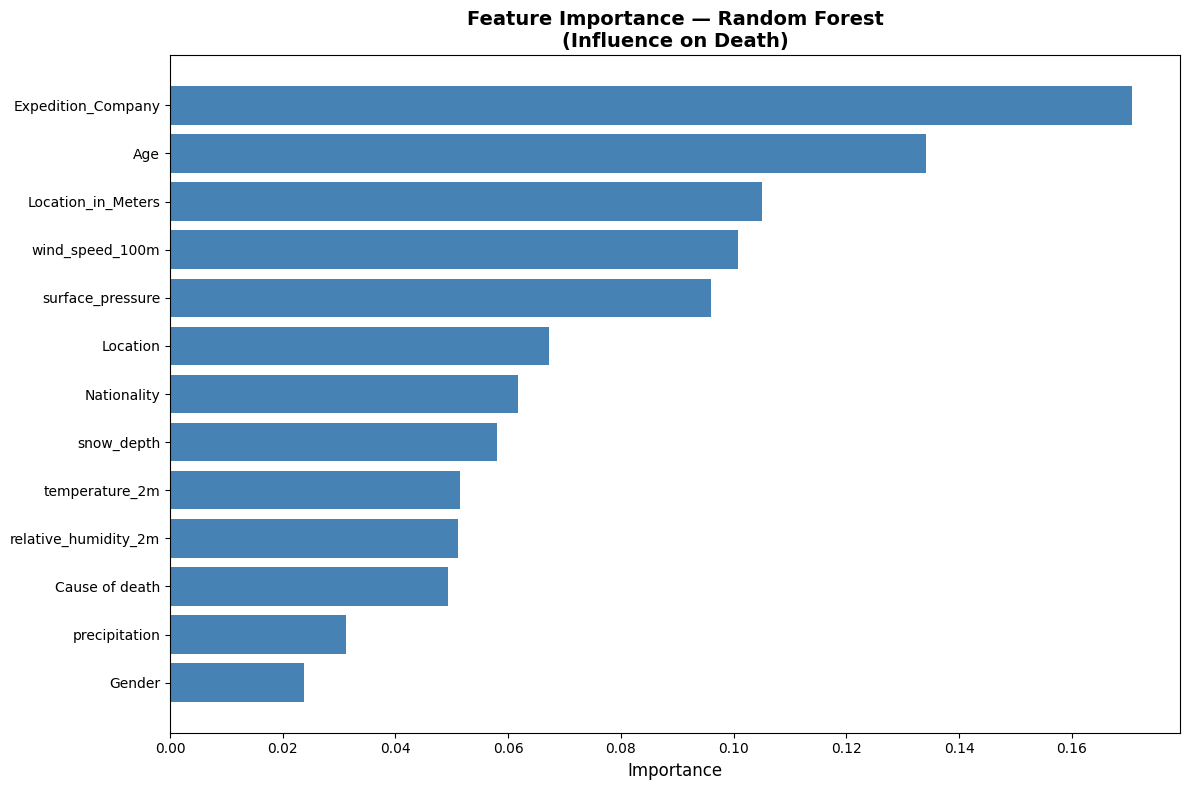

In [13]:
print("=" * 80)
print("MACHINE LEARNING WITH WEATHER DATA")
print("Predicting: Experience Level")
print("=" * 80)

# ── 1. Select features ────────────────────────────────────────────────────────
feature_cols_raw = [
    'Age', 'Gender', 'Nationality', 'Location', 'Location_in_Meters',
    'Cause of death', 'Expedition_Company',
    # Weather
    'temperature_2m', 'wind_speed_100m', 'precipitation',
    'snow_depth', 'relative_humidity_2m', 'surface_pressure'
]
target_col = 'Experience_Level'

ml_df = everest_with_weather[feature_cols_raw + [target_col]].copy()
ml_df = ml_df.dropna()

# ── Remove Experience_Level classes with too few samples ──────────────────────
class_counts = ml_df[target_col].value_counts()
valid_classes = class_counts[class_counts >= 2].index
ml_df = ml_df[ml_df[target_col].isin(valid_classes)]

print(f"Dataset size after dropping rare classes: {len(ml_df)} records")
print(f"Remaining classes: {sorted(ml_df[target_col].unique())}")

print(f"Dataset size after dropping nulls: {len(ml_df)} records")

# ── 2. Encode categorical columns ─────────────────────────────────────────────
categorical_cols = ['Gender', 'Nationality', 'Location', 'Location_in_Meters',
                    'Cause of death', 'Expedition_Company']

encoders = {}
for col in categorical_cols:
    encoders[col] = LabelEncoder()
    ml_df[f'{col}_encoded'] = encoders[col].fit_transform(ml_df[col].astype(str))

# ── 3. Build feature matrix ───────────────────────────────────────────────────
encoded_cols = [f'{col}_encoded' for col in categorical_cols]
numeric_cols = ['Age', 'temperature_2m', 'wind_speed_100m', 'precipitation',
                'snow_depth', 'relative_humidity_2m', 'surface_pressure']

X = ml_df[numeric_cols + encoded_cols]
y = ml_df[target_col]

print(f"Features used: {list(X.columns)}")
print(f"Target classes: {sorted(y.unique())}")

# ── 4. Train/test split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ── 5. Define models ──────────────────────────────────────────────────────────
models = {
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Decision Tree':     DecisionTreeClassifier(random_state=42)
}

# ── 6. Train & evaluate ───────────────────────────────────────────────────────
results = []

print("\nMODEL COMPARISON")
print("=" * 80)

for name, model in models.items():
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score  = model.score(X_test,  y_test)
    cv_scores   = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    results.append({
        'Model':         name,
        'Train Accuracy': train_score,
        'Test Accuracy':  test_score,
        'CV Accuracy':    cv_scores.mean()
    })

    print(f"{name:20s} | Train: {train_score:.2%} | Test: {test_score:.2%} | CV: {cv_scores.mean():.2%}")

# ── 7. Pick best model ────────────────────────────────────────────────────────
results_df    = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
best_name     = results_df.iloc[0]['Model']
best_model    = models[best_name]

print(f"\n🏆 WINNER: {best_name} with {results_df.iloc[0]['Test Accuracy']:.2%} test accuracy")

# ── 8. Classification report ──────────────────────────────────────────────────
print(f"\nCLASSIFICATION REPORT — {best_name}")
print("-" * 80)
print(classification_report(y_test, best_model.predict(X_test)))

# ── 9. Feature importance ─────────────────────────────────────────────────────
if best_name in ['Random Forest', 'Gradient Boosting']:
    feature_labels = numeric_cols + categorical_cols  # human-readable names
    importances    = best_model.feature_importances_

    feature_importance = sorted(
        zip(feature_labels, importances), key=lambda x: x[1], reverse=True
    )

    print(f"\nFEATURE IMPORTANCE — {best_name}")
    print("-" * 80)
    for feat, imp in feature_importance:
        print(f"  {feat:30s}: {imp:.4f} ({imp*100:.1f}%)")

    # Plot
    feats, vals = zip(*feature_importance)
    plt.figure(figsize=(12, 8))
    plt.barh(feats, vals, color='steelblue')
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Feature Importance — {best_name}\n(Influence on Death)',
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('images/everest_feature_importance_weather.png', dpi=300, bbox_inches='tight')
    plt.show()

In [14]:
print("\n" + "=" * 80)
print("PREDICT: WILL DEATH OCCUR IN DEATH ZONE? (Binary Classification)")
print("=" * 80)

# 2. Create binary target: Death Zone or not
ml_binary = everest_with_weather[[
    'Age', 'Gender', 'Location', 'Experience_Level', 'Expedition_Company',
    'temperature_2m', 'wind_speed_100m', 'precipitation', 'snow_depth',
    'Location_in_Meters'
]].copy()

ml_binary = ml_binary.dropna()
ml_binary['in_death_zone'] = (ml_binary['Location_in_Meters'] >= 8000).astype(int)

# Encode
encoders = {}
for col in ['Gender', 'Location', 'Experience_Level', 'Expedition_Company']:
    encoders[col] = LabelEncoder()
    ml_binary[f'{col}_encoded'] = encoders[col].fit_transform(ml_binary[col])

X_binary = ml_binary[['Age', 'Gender_encoded', 'Location_encoded',
                      'Experience_Level_encoded', 'Expedition_Company_encoded',
                      'temperature_2m', 'wind_speed_100m', 'precipitation', 'snow_depth']]
y_binary = ml_binary['in_death_zone']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_binary, y_binary, 
                                                              test_size=0.25, random_state=42)

rf_binary = RandomForestClassifier(n_estimators=100, random_state=42)
rf_binary.fit(X_train_b, y_train_b)

print(f"Train Accuracy: {rf_binary.score(X_train_b, y_train_b):.2%}")
print(f"Test Accuracy: {rf_binary.score(X_test_b, y_test_b):.2%}")

# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

y_pred = rf_binary.predict(X_test_b)
cm = confusion_matrix(y_test_b, y_pred)

print("\nConfusion Matrix:")
print(f"                Predicted: Below   Predicted: Death Zone")
print(f"Actual: Below        {cm[0,0]:3d}              {cm[0,1]:3d}")
print(f"Actual: Death Zone   {cm[1,0]:3d}              {cm[1,1]:3d}")

print("\nClassification Report:")
print(classification_report(y_test_b, y_pred, target_names=['Below Death Zone', 'Death Zone']))


PREDICT: WILL DEATH OCCUR IN DEATH ZONE? (Binary Classification)
Train Accuracy: 100.00%
Test Accuracy: 92.31%

Confusion Matrix:
                Predicted: Below   Predicted: Death Zone
Actual: Below          6                1
Actual: Death Zone     0                6

Classification Report:
                  precision    recall  f1-score   support

Below Death Zone       1.00      0.86      0.92         7
      Death Zone       0.86      1.00      0.92         6

        accuracy                           0.92        13
       macro avg       0.93      0.93      0.92        13
    weighted avg       0.93      0.92      0.92        13




WEATHER SEVERITY ANALYSIS
Weather Severity Score Distribution:
weather_severity_score
0    226
1     76
2      6
3      2
Name: count, dtype: int64

Deaths by Weather Severity:
                        Deaths  temperature_2m  wind_speed_100m Cause of death
weather_severity_score                                                        
0                          225      -26.112888         6.726324           Fall
1                           76      -23.767836         8.254178      Avalanche
2                            6      -38.186611         9.378631           Fall
3                            2      -36.228832        13.339194  Disappearance


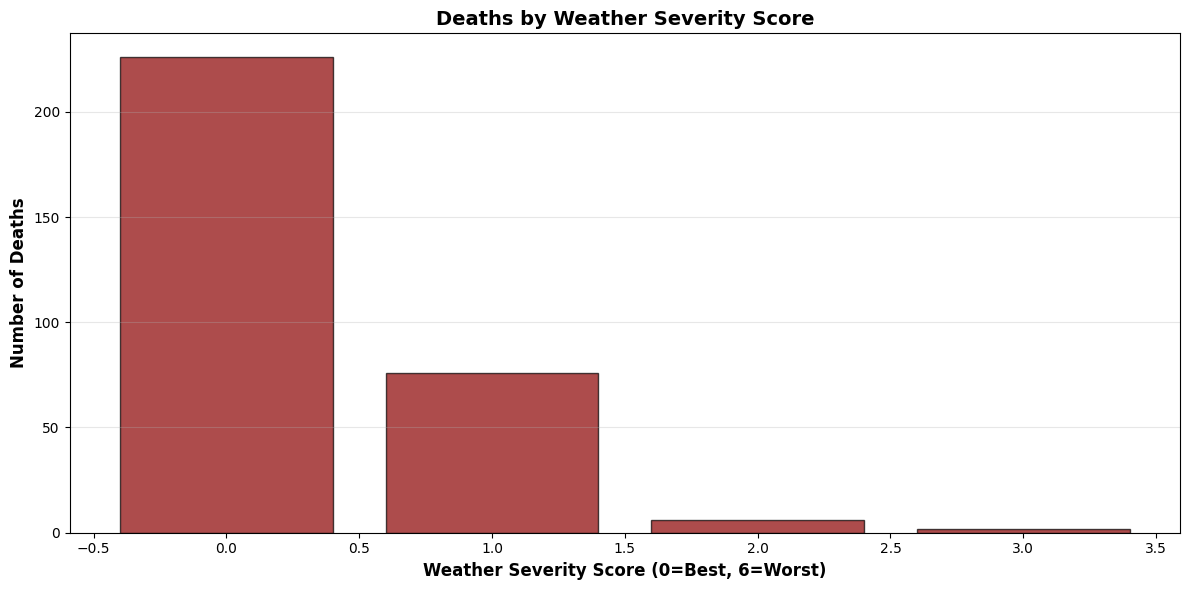

In [15]:
print("\n" + "=" * 80)
print("WEATHER SEVERITY ANALYSIS")
print("=" * 80)

# 3. Create composite weather severity score
everest_with_weather['weather_severity_score'] = (
    ((everest_with_weather['temperature_2m'] < -35).astype(int) * 2) +  # Extreme cold = 2 points
    ((everest_with_weather['wind_speed_100m'] > 25).astype(int) * 2) +  # High wind = 2 points
    ((everest_with_weather['precipitation'] > 2).astype(int) * 1) +     # Precipitation = 1 point
    ((everest_with_weather['snow_depth'] > 30).astype(int) * 1)         # Deep snow = 1 point
)

print("Weather Severity Score Distribution:")
print(everest_with_weather['weather_severity_score'].value_counts().sort_index())

# Deaths by severity score
print("\nDeaths by Weather Severity:")
severity_deaths = everest_with_weather.groupby('weather_severity_score').agg({
    'Name': 'count',
    'temperature_2m': 'mean',
    'wind_speed_100m': 'mean',
    'Cause of death': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A'
}).rename(columns={'Name': 'Deaths'})
print(severity_deaths)

# Visualize
plt.figure(figsize=(12, 6))
plt.bar(everest_with_weather['weather_severity_score'].value_counts().sort_index().index,
        everest_with_weather['weather_severity_score'].value_counts().sort_index().values,
        color='darkred',
        edgecolor='black',
        alpha=0.7)
plt.xlabel('Weather Severity Score (0=Best, 6=Worst)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Deaths', fontsize=12, fontweight='bold')
plt.title('Deaths by Weather Severity Score', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('images/everest_weather_severity_deaths.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
ml_weather = everest_with_weather[[
    'Age', 'Gender', 'Location', 'Experience_Level', 'Expedition_Company',
    'temperature_2m', 'wind_speed_100m', 'precipitation', 'snow_depth',
    'Location_in_Meters', 'Cause of death'
]].copy()
ml_weather = ml_weather.dropna()

for col in ['Gender', 'Location', 'Experience_Level', 'Expedition_Company']:
    ml_weather[f'{col}_encoded'] = encoders[col].fit_transform(ml_weather[col])

print("\n" + "=" * 80)
print("PREDICT DEATH ALTITUDE WITH WEATHER (Regression)")
print("=" * 80)

# 4. Predict Specific Altitude of Death (Regression with Weather)

altitude_ml = everest_with_weather[[
    'Age', 'Gender', 'Location', 'Experience_Level', 'Expedition_Company',
    'temperature_2m', 'wind_speed_100m', 'precipitation', 'snow_depth',
    'Location_in_Meters'
]].copy()

altitude_ml = altitude_ml.dropna()

# Encode
for col in ['Gender', 'Location', 'Experience_Level', 'Expedition_Company']:
    altitude_ml[f'{col}_encoded'] = encoders[col].fit_transform(altitude_ml[col])

X_alt = altitude_ml[['Age', 'Gender_encoded', 'Location_encoded',
                     'Experience_Level_encoded', 'Expedition_Company_encoded',
                     'temperature_2m', 'wind_speed_100m', 'precipitation', 'snow_depth']]
y_alt = altitude_ml['Location_in_Meters']

X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(
    X_alt, y_alt, test_size=0.25, random_state=42)

rf_altitude = RandomForestRegressor(n_estimators=100, random_state=42)
rf_altitude.fit(X_train_alt, y_train_alt)

train_pred = rf_altitude.predict(X_train_alt)
test_pred = rf_altitude.predict(X_test_alt)

train_r2 = r2_score(y_train_alt, train_pred)
test_r2 = r2_score(y_test_alt, test_pred)
test_mae = mean_absolute_error(y_test_alt, test_pred)

print(f"Train R²: {train_r2:.3f}")
print(f"Test R²: {test_r2:.3f}")
print(f"Mean Absolute Error: {test_mae:.0f} meters")

if test_r2 > 0:
    print(f"\n✓ Model can predict altitude with {test_r2*100:.1f}% variance explained")
else:
    print(f"\n✗ Model performs worse than baseline (negative R²)")


PREDICT DEATH ALTITUDE WITH WEATHER (Regression)
Train R²: 0.910
Test R²: 0.716
Mean Absolute Error: 548 meters

✓ Model can predict altitude with 71.6% variance explained


In [17]:
print("\n" + "=" * 80)
print("COMPARISON: MODELS WITH vs WITHOUT WEATHER DATA")
print("=" * 80)
# 5. With Weather vs Without Weather
# Without weather (from before)
X_no_weather = ml_weather[['Age', 'Gender_encoded', 'Location_encoded',
                            'Experience_Level_encoded', 'Expedition_Company_encoded']]
y_no_weather = ml_weather['Cause of death']

X_train_nw, X_test_nw, y_train_nw, y_test_nw = train_test_split(
    X_no_weather, y_no_weather, test_size=0.25, random_state=42)

rf_no_weather = RandomForestClassifier(n_estimators=100, random_state=42)
rf_no_weather.fit(X_train_nw, y_train_nw)

# With weather (already trained above)
score_without = rf_no_weather.score(X_test_nw, y_test_nw)
score_with = best_model.score(X_test, y_test)

print(f"Accuracy WITHOUT weather: {score_without:.2%}")
print(f"Accuracy WITH weather:    {score_with:.2%}")
print(f"Improvement:              {(score_with - score_without)*100:.1f} percentage points")

if score_with > score_without:
    print("\n✓ Weather data IMPROVES predictions!")
else:
    print("\n✗ Weather data does NOT improve predictions significantly")


COMPARISON: MODELS WITH vs WITHOUT WEATHER DATA
Accuracy WITHOUT weather: 38.46%
Accuracy WITH weather:    23.08%
Improvement:              -15.4 percentage points

✗ Weather data does NOT improve predictions significantly
